In [1]:
import numpy as np 
import pandas as pd

data = pd.read_csv("Food_Delivery_Time_Prediction.csv")

print(data.head(5))

  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon          Car                4.1 

In [2]:
print(data.shape[0])
print(data.shape[1])

200
15


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [4]:
print(data.isnull().sum())

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64


In [5]:
data[['cust_lat','cust_lon']] = data['Customer_Location']\
.str.strip('()').str.split(',',expand=True).astype(float)

data[['rest_lat','rest_lon']] = data['Restaurant_Location']\
.str.strip('()').str.split(',',expand=True).astype(float)

data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,cust_lat,cust_lon,rest_lat,rest_lon
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,17.030479,79.743077,12.358515,85.100083
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,15.398319,86.639122,14.174874,77.025606
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,15.687342,83.888808,19.594748,82.048482
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,20.415599,78.046984,16.915906,78.278698
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,14.786904,78.706532,15.206038,86.203182


In [6]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):

    R = 6371  # Earth radius (km)

    lat1, lon1, lat2, lon2 = map(np.radians,
                                 [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))

    return R*c


data['Calculated_Distance'] = haversine(
    data['cust_lat'],
    data['cust_lon'],
    data['rest_lat'],
    data['rest_lon']
)

In [7]:
data[['Distance','Calculated_Distance']].head()

,Distance,Calculated_Distance
0,1.57,775.651198
1,21.32,1042.385597
2,6.95,476.220706
3,13.79,389.912629
4,6.72,806.505886


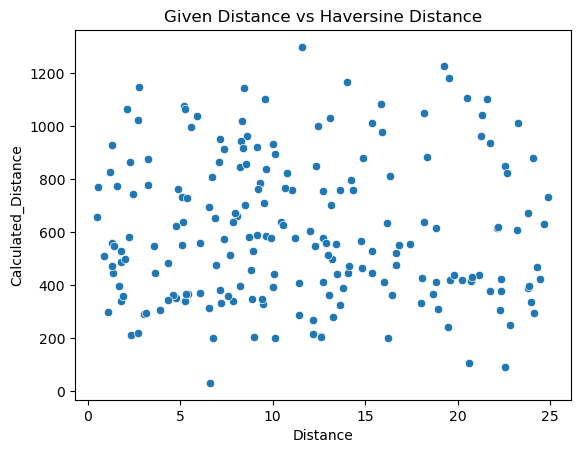

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='Distance',y='Calculated_Distance',data=data)
plt.title("Given Distance vs Haversine Distance")
plt.show()

In [9]:
data['Rush_Hour'] = data['Order_Time'].apply(
    lambda x: 1 if x in ['Morning','Evening'] else 0
)

traffic_map = {
    'Low':1,
    'Medium':2,
    'High':3
}

data['Traffic_Level'] = data['Traffic_Conditions'].map(traffic_map)
data['Traffic_Distance'] = data['Traffic_Level'] * data['Distance']
data['Experience_per_KM'] = data['Delivery_Person_Experience'] / (data['Distance'] + 1)
data['Cost_per_KM'] = data['Order_Cost'] / (data['Distance'] + 1)

In [10]:
categorical_cols = [
    'Weather_Conditions',
    'Traffic_Conditions',
    'Vehicle_Type',
    'Order_Priority',
    'Order_Time'
]

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [11]:
# Target variable
y = data['Delivery_Time']

# Features
X = data.drop([
    'Delivery_Time',
    'Order_ID',
    'Customer_Location',
    'Restaurant_Location'
], axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [
    'Distance',
    'Delivery_Person_Experience',
    'Restaurant_Rating',
    'Customer_Rating',
    'Order_Cost',
    'Tip_Amount',
    'Calculated_Distance'
]

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [13]:
X_train.head()

,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount,cust_lat,cust_lon,rest_lat,rest_lon,...,Weather_Conditions_Sunny,Traffic_Conditions_Low,Traffic_Conditions_Medium,Vehicle_Type_Bike,Vehicle_Type_Car,Order_Priority_Low,Order_Priority_Medium,Order_Time_Evening,Order_Time_Morning,Order_Time_Night
79,1.876208,0.586472,1.286739,-1.252812,-0.022890,1.323450,21.460760,79.294489,17.241296,79.143973,...,False,False,False,False,False,False,False,False,False,False
197,1.344980,-0.508884,-1.207865,-0.406437,0.565571,-1.412953,14.575401,82.556410,13.625369,82.418092,...,False,False,False,True,False,False,True,False,False,False
38,-0.957493,1.316710,0.259549,-0.547499,-1.080649,-1.423291,17.690598,83.089253,12.165091,82.247130,...,True,True,False,False,True,False,True,False,False,False
24,-0.044945,-0.143766,-0.914382,1.286315,1.523490,-0.842998,17.731821,80.929601,14.154959,86.969719,...,True,False,True,True,False,False,True,True,False,False
122,-0.254526,1.316710,-0.033934,-0.829624,-1.503929,-1.004612,18.383287,85.635688,13.553503,87.773861,...,True,False,True,False,False,False,False,False,False,True


In [14]:
numeric_data = data.select_dtypes(include=['number','bool'])
corr_with_target = numeric_data.corr()['Delivery_Time'].sort_values(ascending=False)
print(corr_with_target)

Delivery_Time                 1.000000
rest_lon                      0.083964
Weather_Conditions_Rainy      0.054402
Experience_per_KM             0.046543
Traffic_Conditions_Low        0.039714
rest_lat                      0.018548
Order_Priority_Low            0.012849
Order_Time_Morning            0.011984
Traffic_Conditions_Medium     0.011810
cust_lon                      0.008253
Rush_Hour                     0.005871
Vehicle_Type_Car             -0.001372
Order_Time_Evening           -0.004021
Cost_per_KM                  -0.008663
Order_Cost                   -0.009307
Order_Time_Night             -0.013972
Order_Priority_Medium        -0.017798
Delivery_Person_Experience   -0.019098
Weather_Conditions_Sunny     -0.020492
Customer_Rating              -0.021952
Weather_Conditions_Snowy     -0.024621
Tip_Amount                   -0.029154
cust_lat                     -0.037146
Traffic_Level                -0.055840
Distance                     -0.075143
Traffic_Distance         

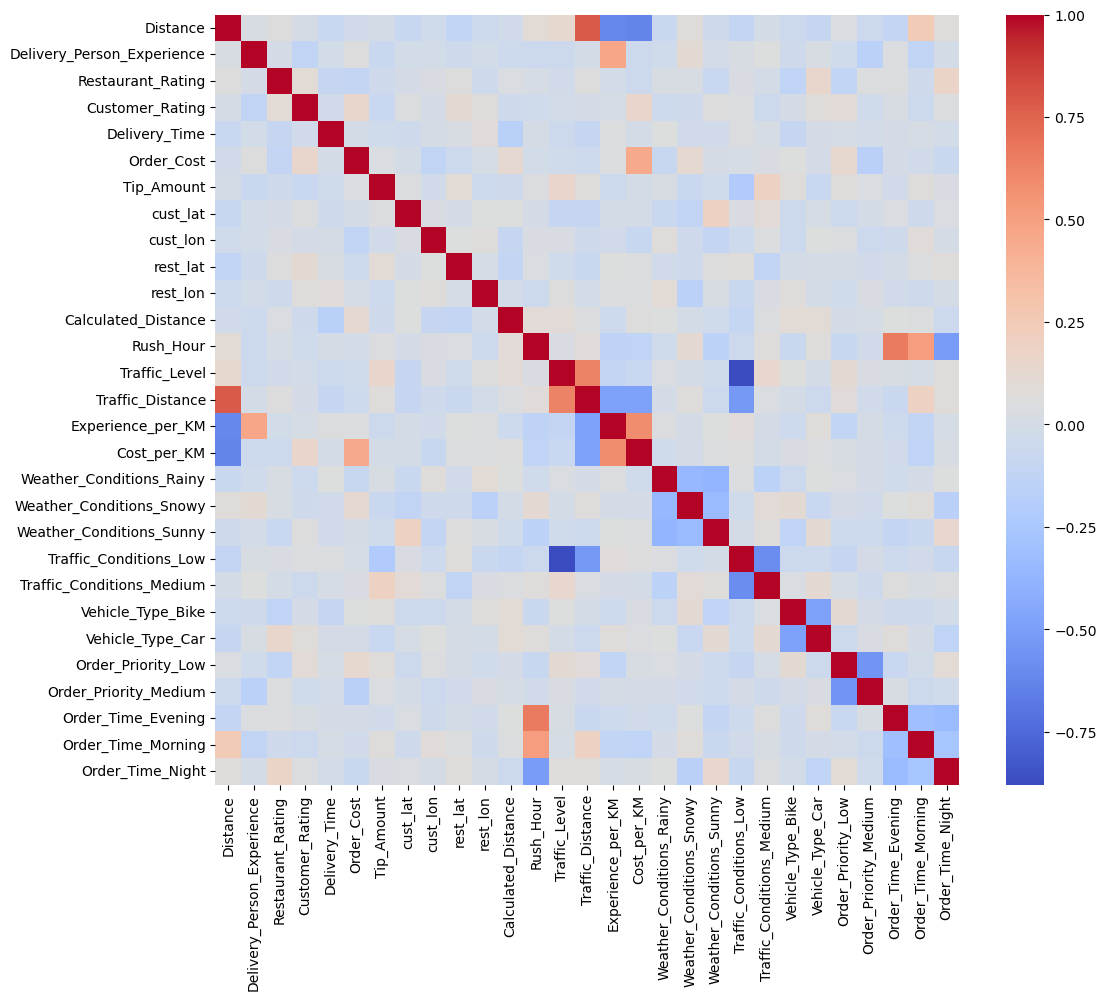

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt



correlation_matrix =data.select_dtypes(include=['number','bool']).corr()
plt.figure(figsize = (12,10))
sns.heatmap(correlation_matrix, cmap = 'coolwarm')
plt.show()

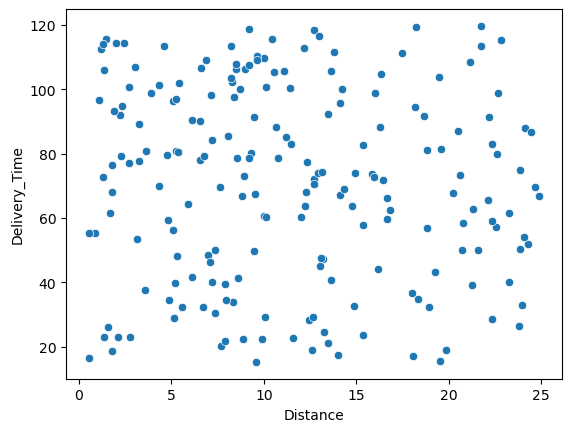

In [16]:
sns.scatterplot(x='Distance', y='Delivery_Time', data=data)
plt.show()

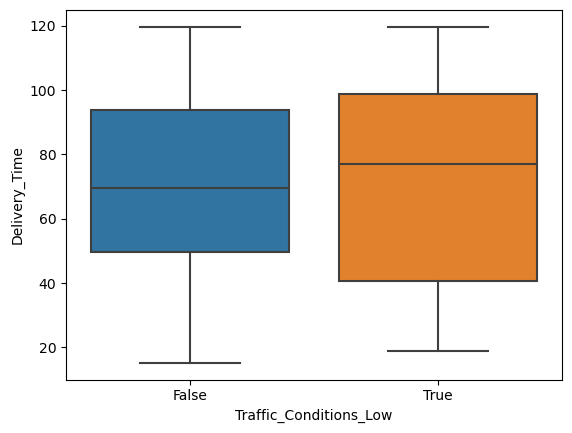

In [17]:
sns.boxplot(x='Traffic_Conditions_Low', y='Delivery_Time', data=data)
plt.show()

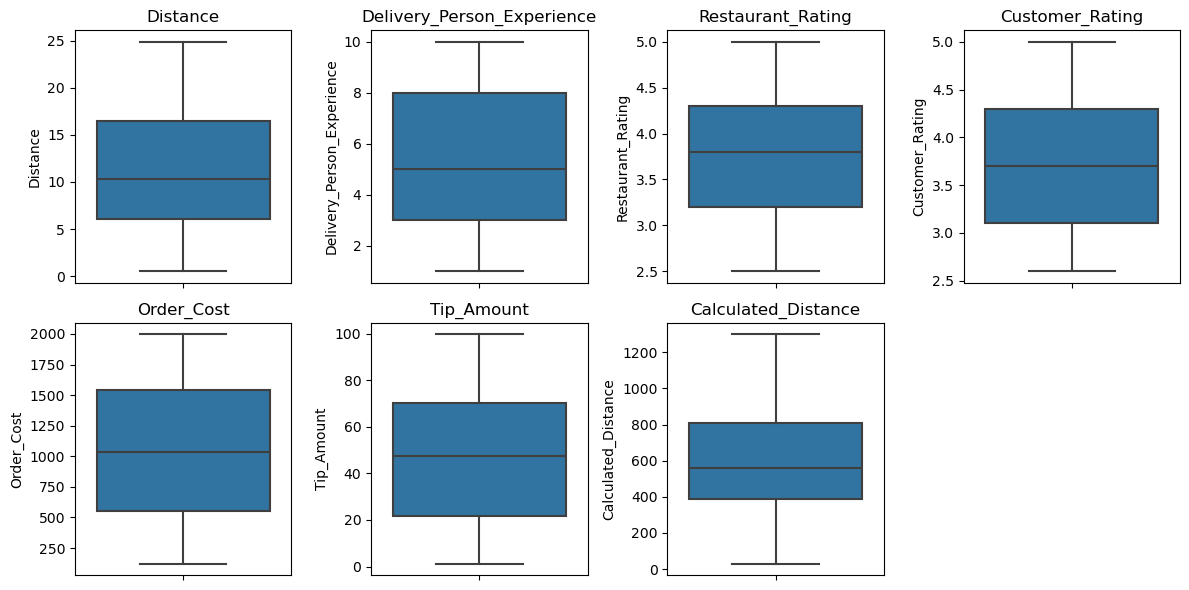

In [18]:
plt.figure(figsize=(12,6))

for i, col in enumerate(numeric_cols):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
#handling outliers

Q1 = data['Delivery_Time'].quantile(0.25)
Q3 = data['Delivery_Time'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['Delivery_Time'] >= lower) & 
        (data['Delivery_Time'] <= upper)]

In [20]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)

Linear Regression Results
MSE: 1087.12742233244
MAE: 27.7799316702047
R²: -0.175411130778947


In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Results")
print("MSE:", mse_poly)
print("MAE:", mae_poly)
print("R²:", r2_poly)
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression"],
    "MSE": [mse, mse_poly],
    "MAE": [mae, mae_poly],
    "R2 Score": [r2, r2_poly]
})

comparison

Polynomial Regression Results
MSE: 7390.236587280999
MAE: 61.165794138216576
R²: -6.9903847197072935


,Model,MSE,MAE,R2 Score
0,Linear Regression,1087.127422,27.779932,-0.175411
1,Polynomial Regression,7390.236587,61.165794,-6.990385


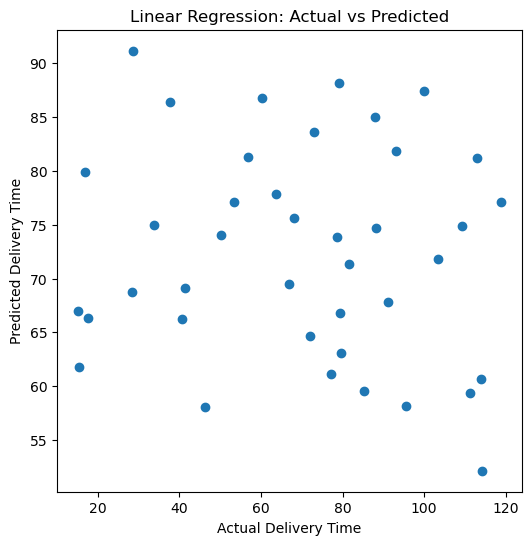

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

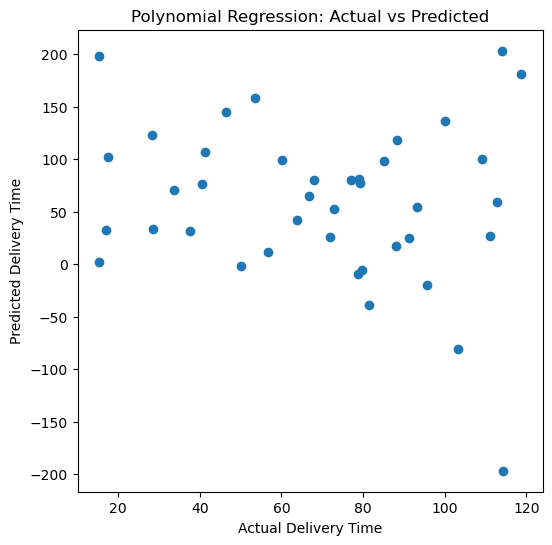

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_poly)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.show()

In [24]:
median_time = data['Delivery_Time'].median()

data['Delivery_Status'] = data['Delivery_Time'].apply(
    lambda x: 1 if x > median_time else 0
)

In [25]:
X = data.drop([
    'Delivery_Time',
    'Delivery_Status',
    'Order_ID',
    'Customer_Location',
    'Restaurant_Location'
], axis=1)

y = data['Delivery_Status']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    'Distance',
    'Delivery_Person_Experience',
    'Restaurant_Rating',
    'Customer_Rating',
    'Order_Cost',
    'Tip_Amount',
    'Calculated_Distance'
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [27]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter = 10000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.45
Precision: 0.4782608695652174
Recall: 0.5238095238095238
F1 Score: 0.5


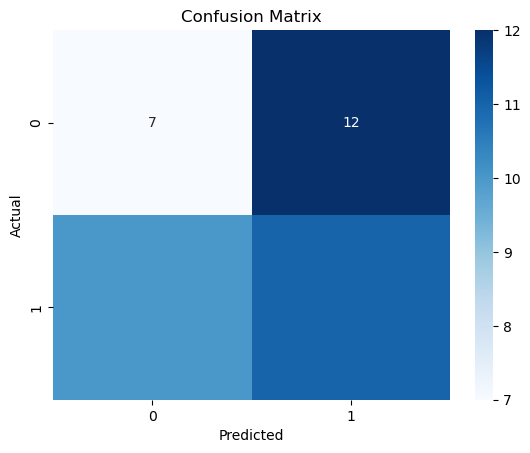

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

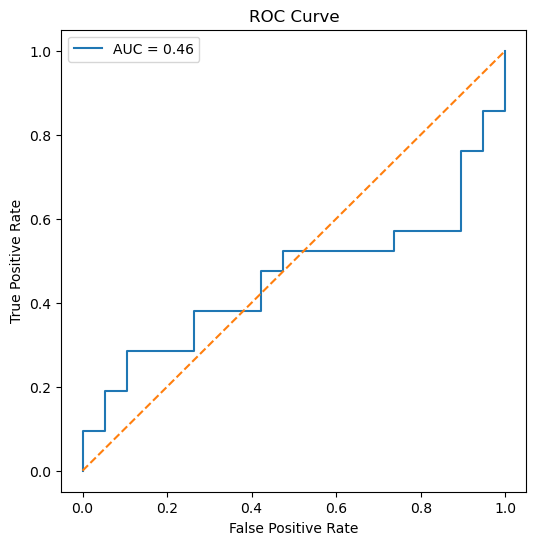

In [29]:
from sklearn.metrics import roc_curve, auc

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()